# Análise exploratória SINAN: Ilhéus e Itabuna (2014-2024)

Este notebook parte dos CSVs já baixados e validados pelo script `sinan_pipeline.py`. Aqui ficam apenas a análise exploratória, as séries temporais e os rankings das cidades.

In [1]:
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from sinan_pipeline import (
    AGRAVO_LABELS,
    AGRAVOS_ALVO,
    ANOS_ALVO,
    CITY_CODES,
    DATA_DIR,
    audit_downloads,
    build_candidate_inventory,
    build_city_counts,
    build_expected_file_map,
    build_monthly_city_counts,
    build_rankings,
    plot_rankings,
    summarize_audit,
)

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

expected_total_files = len(AGRAVOS_ALVO) * len(ANOS_ALVO)
print(f"Agravos no escopo: {len(AGRAVOS_ALVO)}")
print(f"Período: {ANOS_ALVO[0]} a {ANOS_ALVO[-1]}")
print(f"Arquivos esperados: {expected_total_files}")
print(f"Cidades: {CITY_CODES}")

Agravos no escopo: 28
Período: 2014 a 2024
Arquivos esperados: 308
Cidades: {'Ilhéus': 291360, 'Itabuna': 291480}


## 1. Carregamento local e qualidade da base



In [2]:
_, expected_file_map = build_expected_file_map(
    AGRAVOS_ALVO,
    ANOS_ALVO,
    use_remote_catalog=False,
)

download_audit_df = audit_downloads(expected_file_map, DATA_DIR)
audit_summary_df = summarize_audit(download_audit_df)

display(audit_summary_df)

pendencias_df = download_audit_df.loc[
    download_audit_df["needs_download"] | download_audit_df["needs_reconvert"],
    ["agravo", "agravo_nome", "ano", "status", "csv_state", "parquet_state"],
].reset_index(drop=True)

if pendencias_df.empty:
    print("Base local completa para o escopo definido.")
else:
    print("Arquivos que ainda merecem nova tentativa pelo script de dados:")
    display(pendencias_df)

city_counts_df, skipped_files_df = build_city_counts(
    download_audit_df,
    CITY_CODES,
    DATA_DIR,
    AGRAVO_LABELS,
)
serie_anual_df = city_counts_df.copy()
ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df = build_rankings(city_counts_df)

if not skipped_files_df.empty:
    print("Arquivos ignorados por problema estrutural:")
    display(skipped_files_df)

assert len(expected_file_map) == expected_total_files
assert (city_counts_df["casos"] <= city_counts_df["linhas_arquivo"]).all()
assert set(city_counts_df.loc[city_counts_df["agravo"] == "TRAC", "cidade_coluna"].unique()) == {"ID_MUNI_RE"}
assert set(city_counts_df.loc[city_counts_df["agravo"] == "NTRA", "cidade_coluna"].unique()) == {"ID_MUNICIP"}
print("Base analítica carregada com sucesso.")

,status,needs_download,needs_reconvert,arquivos
0,empty,False,False,8
1,present,False,False,300


Base local completa para o escopo definido.
Base analítica carregada com sucesso.


## 2. Panorama geral

Primeiro olhamos o volume total, quantos agravos tiveram notificações em cada cidade e como a série anual se comporta no período.

In [3]:
totais_cidade_df = (
    serie_anual_df.groupby("cidade", as_index=False)["casos"]
    .sum()
    .rename(columns={"casos": "total_notificacoes"})
    .sort_values("total_notificacoes", ascending=False)
)

agravos_ativos_df = (
    serie_anual_df.groupby(["cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
    .query("casos > 0")
    .groupby("cidade", as_index=False)
    .agg(agravos_com_notificacao=("agravo", "nunique"))
)

resumo_geral_df = totais_cidade_df.merge(agravos_ativos_df, on="cidade", how="left")
resumo_geral_df["media_anual"] = resumo_geral_df["total_notificacoes"] / len(ANOS_ALVO)
resumo_geral_df["media_anual"] = resumo_geral_df["media_anual"].round(1)

totais_ano_df = (
    serie_anual_df.groupby(["ano", "cidade"], as_index=False)["casos"]
    .sum()
    .pivot(index="ano", columns="cidade", values="casos")
    .fillna(0)
    .astype(int)
)
totais_ano_df["Total"] = totais_ano_df.sum(axis=1)

display(resumo_geral_df)
display(totais_ano_df)

,cidade,total_notificacoes,agravos_com_notificacao,media_anual
0,Itabuna,5420,18,492.7
1,Ilhéus,4417,20,401.5


cidade,Ilhéus,Itabuna,Total
ano,,,
2014,395,545,940
2015,380,483,863
2016,324,531,855
2017,375,575,950
2018,426,553,979
2019,497,583,1080
2020,282,391,673
2021,417,489,906
2022,569,525,1094


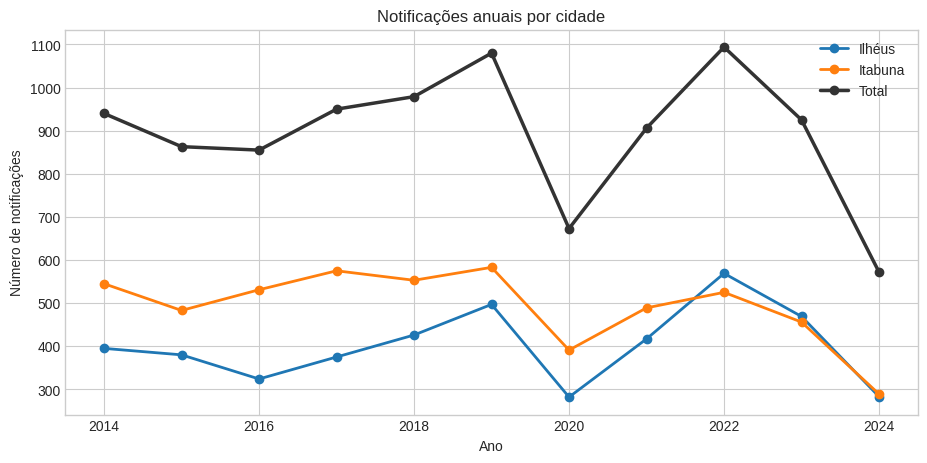

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
for cidade in CITY_CODES:
    ax.plot(totais_ano_df.index, totais_ano_df[cidade], marker="o", linewidth=2, label=cidade)
ax.plot(totais_ano_df.index, totais_ano_df["Total"], marker="o", linewidth=2.5, color="#333333", label="Total")
ax.set_title("Notificações anuais por cidade")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de notificações")
ax.legend()
plt.show()

## 3. Rankings e concentração

Aqui mantemos o top 10 principal, mas também medimos o quanto poucos agravos concentram o total de notificações.

In [5]:
print("Top 10 - Ilhéus")
display(ranking_ilheus_df)

print("Top 10 - Itabuna")
display(ranking_itabuna_df)

print("Top 10 - Consolidado")
display(ranking_geral_df)

ranking_completo_df = (
    serie_anual_df.groupby(["cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
    .sort_values(["cidade", "casos", "agravo_nome"], ascending=[True, False, True])
)
ranking_completo_df["posicao"] = ranking_completo_df.groupby("cidade")["casos"].rank(
    method="first",
    ascending=False,
).astype(int)

concentracao_df = []
for cidade, grupo in ranking_completo_df.groupby("cidade"):
    total = grupo["casos"].sum()
    concentracao_df.append(
        {
            "cidade": cidade,
            "total_notificacoes": int(total),
            "top_1_pct": round(grupo.head(1)["casos"].sum() / total * 100, 1) if total else 0,
            "top_3_pct": round(grupo.head(3)["casos"].sum() / total * 100, 1) if total else 0,
            "top_10_pct": round(grupo.head(10)["casos"].sum() / total * 100, 1) if total else 0,
        }
    )
concentracao_df = pd.DataFrame(concentracao_df)
display(concentracao_df)

Top 10 - Ilhéus


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1489,Tuberculose (TUBE)
1,2,SIFA,Sífilis Adquirida,714,Sífilis Adquirida (SIFA)
2,3,SIFG,Sífilis em Gestante,564,Sífilis em Gestante (SIFG)
3,4,VARC,Varicela,534,Varicela (VARC)
4,5,SIFC,Sífilis Congênita,316,Sífilis Congênita (SIFC)
5,6,LTAN,Leishmaniose Tegumentar Americana,251,Leishmaniose Tegumentar Americana (LTAN)
6,7,HANS,Hanseníase,173,Hanseníase (HANS)
7,8,LEPT,Leptospirose,148,Leptospirose (LEPT)
8,9,MENI,Meningite,83,Meningite (MENI)
9,10,CHAG,Doença de Chagas Aguda,61,Doença de Chagas Aguda (CHAG)


Top 10 - Itabuna


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,1762,Tuberculose (TUBE)
1,2,SIFA,Sífilis Adquirida,1495,Sífilis Adquirida (SIFA)
2,3,SIFG,Sífilis em Gestante,605,Sífilis em Gestante (SIFG)
3,4,VARC,Varicela,511,Varicela (VARC)
4,5,HANS,Hanseníase,422,Hanseníase (HANS)
5,6,LEPT,Leptospirose,163,Leptospirose (LEPT)
6,7,MENI,Meningite,117,Meningite (MENI)
7,8,SIFC,Sífilis Congênita,116,Sífilis Congênita (SIFC)
8,9,LTAN,Leishmaniose Tegumentar Americana,60,Leishmaniose Tegumentar Americana (LTAN)
9,10,COQU,Coqueluche,42,Coqueluche (COQU)


Top 10 - Consolidado


,posicao,agravo,agravo_nome,casos,agravo_exibicao
0,1,TUBE,Tuberculose,3251,Tuberculose (TUBE)
1,2,SIFA,Sífilis Adquirida,2209,Sífilis Adquirida (SIFA)
2,3,SIFG,Sífilis em Gestante,1169,Sífilis em Gestante (SIFG)
3,4,VARC,Varicela,1045,Varicela (VARC)
4,5,HANS,Hanseníase,595,Hanseníase (HANS)
5,6,SIFC,Sífilis Congênita,432,Sífilis Congênita (SIFC)
6,7,LTAN,Leishmaniose Tegumentar Americana,311,Leishmaniose Tegumentar Americana (LTAN)
7,8,LEPT,Leptospirose,311,Leptospirose (LEPT)
8,9,MENI,Meningite,200,Meningite (MENI)
9,10,CHAG,Doença de Chagas Aguda,61,Doença de Chagas Aguda (CHAG)


,cidade,total_notificacoes,top_1_pct,top_3_pct,top_10_pct
0,Ilhéus,4417,33.7,62.6,98.1
1,Itabuna,5420,32.5,71.3,97.7


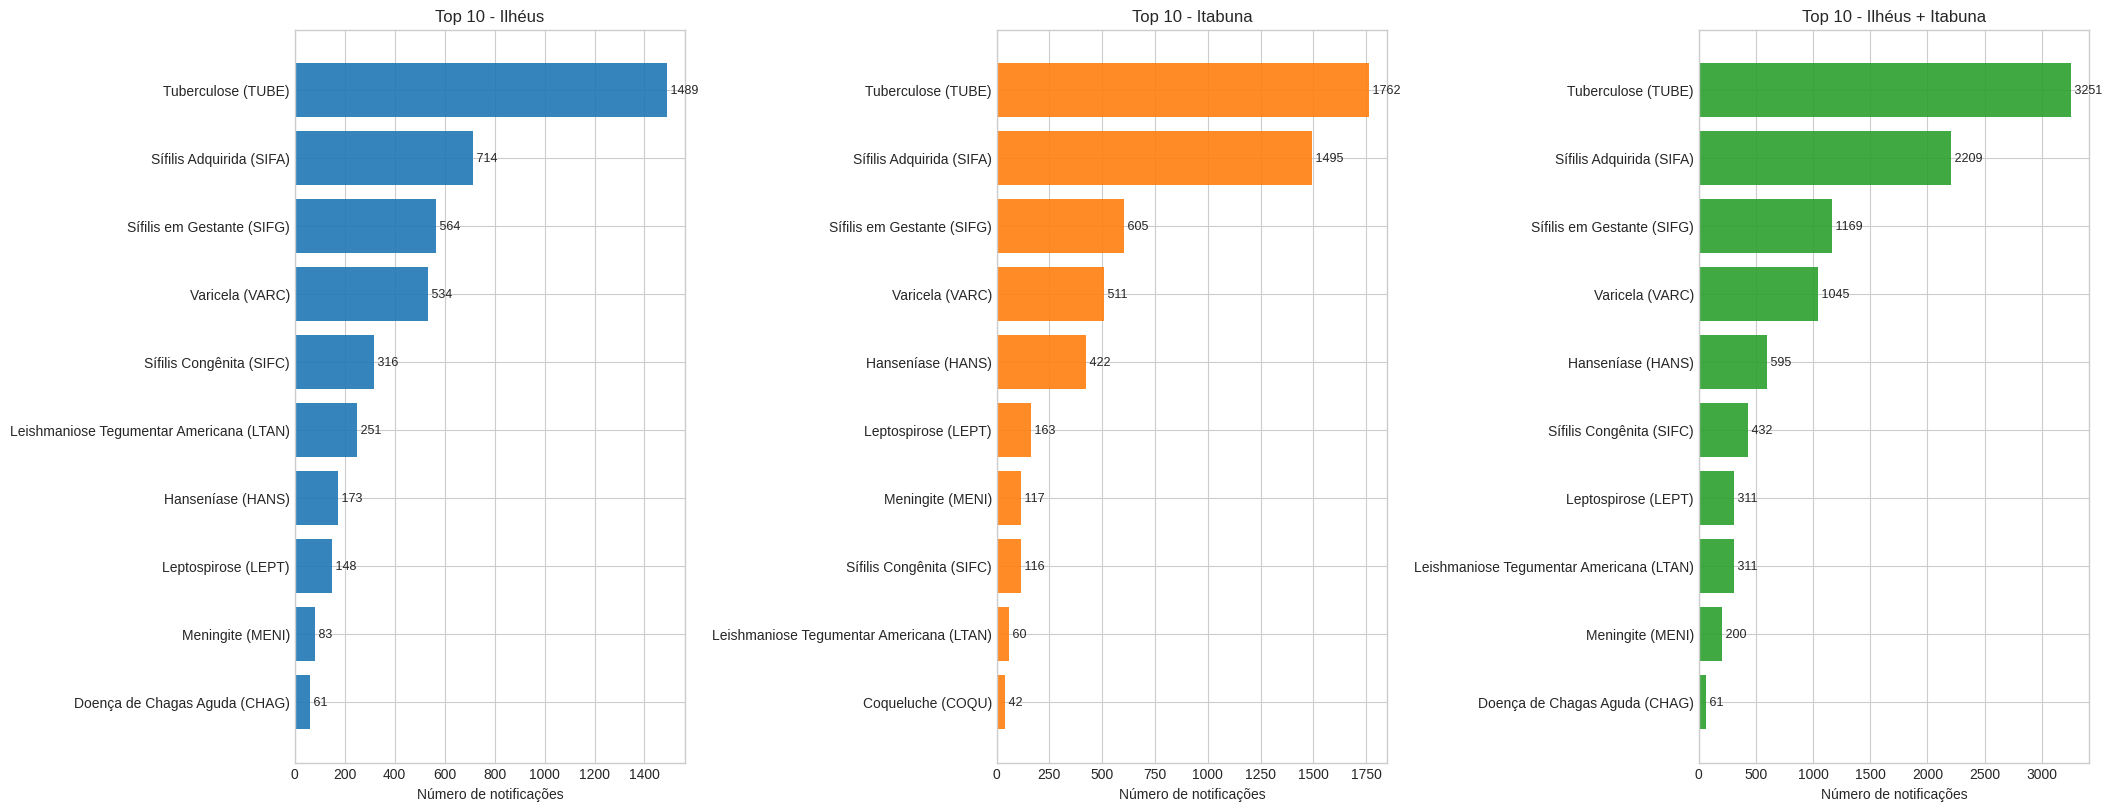

In [6]:
fig, axes = plot_rankings(ranking_ilheus_df, ranking_itabuna_df, ranking_geral_df)
plt.show()

## 4. Comparação entre Ilhéus e Itabuna

Este recorte mostra quais agravos pesam mais em uma cidade do que na outra, incluindo diferença absoluta e razão entre os volumes.

cidade,agravo,agravo_nome,Ilhéus,Itabuna,Total,diferenca_itabuna_menos_ilheus,razao_itabuna_ilheus,cidade_maior_volume
0,TUBE,Tuberculose,1489,1762,3251,273,1.18,Itabuna
1,SIFA,Sífilis Adquirida,714,1495,2209,781,2.09,Itabuna
2,SIFG,Sífilis em Gestante,564,605,1169,41,1.07,Itabuna
3,VARC,Varicela,534,511,1045,-23,0.96,Ilhéus
4,HANS,Hanseníase,173,422,595,249,2.44,Itabuna
5,SIFC,Sífilis Congênita,316,116,432,-200,0.37,Ilhéus
6,LTAN,Leishmaniose Tegumentar Americana,251,60,311,-191,0.24,Ilhéus
7,LEPT,Leptospirose,148,163,311,15,1.10,Itabuna
8,MENI,Meningite,83,117,200,34,1.41,Itabuna
9,CHAG,Doença de Chagas Aguda,61,0,61,-61,0.00,Ilhéus


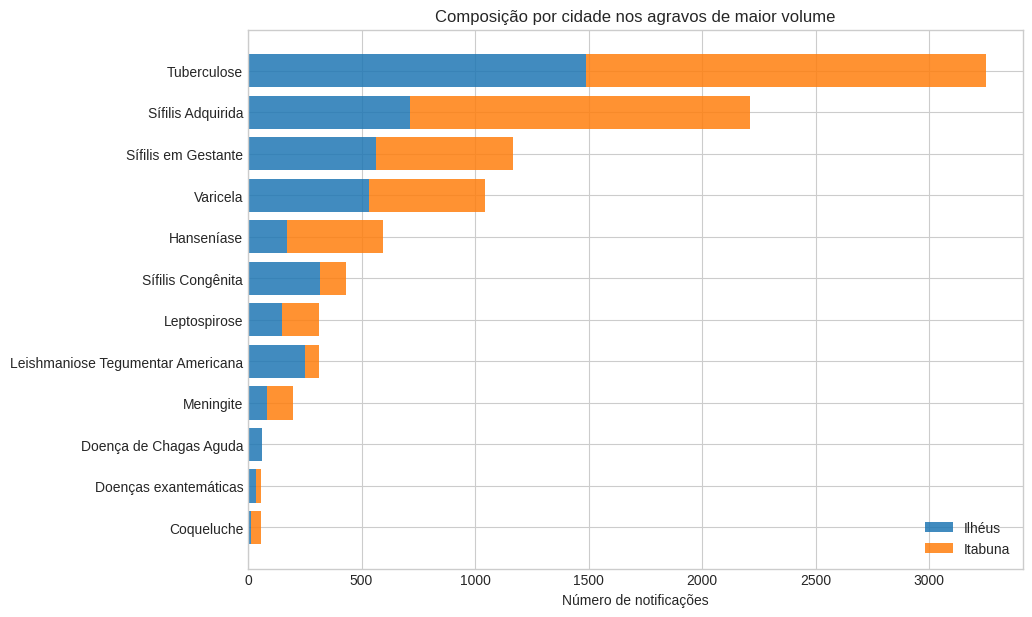

In [7]:
comparacao_cidades_df = (
    serie_anual_df.groupby(["agravo", "agravo_nome", "cidade"], as_index=False)["casos"]
    .sum()
    .pivot(index=["agravo", "agravo_nome"], columns="cidade", values="casos")
    .fillna(0)
    .astype(int)
    .reset_index()
)
comparacao_cidades_df["Total"] = comparacao_cidades_df["Ilhéus"] + comparacao_cidades_df["Itabuna"]
comparacao_cidades_df["diferenca_itabuna_menos_ilheus"] = comparacao_cidades_df["Itabuna"] - comparacao_cidades_df["Ilhéus"]
comparacao_cidades_df["razao_itabuna_ilheus"] = (
    comparacao_cidades_df["Itabuna"] / comparacao_cidades_df["Ilhéus"].replace(0, float("nan"))
).round(2)
comparacao_cidades_df["cidade_maior_volume"] = comparacao_cidades_df.apply(
    lambda row: "Itabuna" if row["Itabuna"] > row["Ilhéus"] else ("Ilhéus" if row["Ilhéus"] > row["Itabuna"] else "Empate"),
    axis=1,
)
comparacao_cidades_df = comparacao_cidades_df.sort_values("Total", ascending=False).reset_index(drop=True)

display(comparacao_cidades_df.head(15))

plot_df = comparacao_cidades_df.head(12).sort_values("Total")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["agravo_nome"], plot_df["Ilhéus"], label="Ilhéus", color="#1f77b4", alpha=0.85)
ax.barh(plot_df["agravo_nome"], plot_df["Itabuna"], left=plot_df["Ilhéus"], label="Itabuna", color="#ff7f0e", alpha=0.85)
ax.set_title("Composição por cidade nos agravos de maior volume")
ax.set_xlabel("Número de notificações")
ax.set_ylabel("")
ax.legend()
plt.show()

## 5. Evolucao temporal dos principais agravos

Agora observamos se os maiores agravos foram constantes no tempo ou se houve picos especificos em alguns anos.

cidade,ano,agravo,agravo_nome,Ilhéus,Itabuna
0,2014,HANS,Hanseníase,16,46
1,2014,SIFA,Sífilis Adquirida,2,110
2,2014,SIFC,Sífilis Congênita,2,10
3,2014,SIFG,Sífilis em Gestante,8,79
4,2014,TUBE,Tuberculose,114,141
5,2014,VARC,Varicela,156,78
6,2015,HANS,Hanseníase,18,38
7,2015,SIFA,Sífilis Adquirida,2,120
8,2015,SIFC,Sífilis Congênita,17,22
9,2015,SIFG,Sífilis em Gestante,35,74


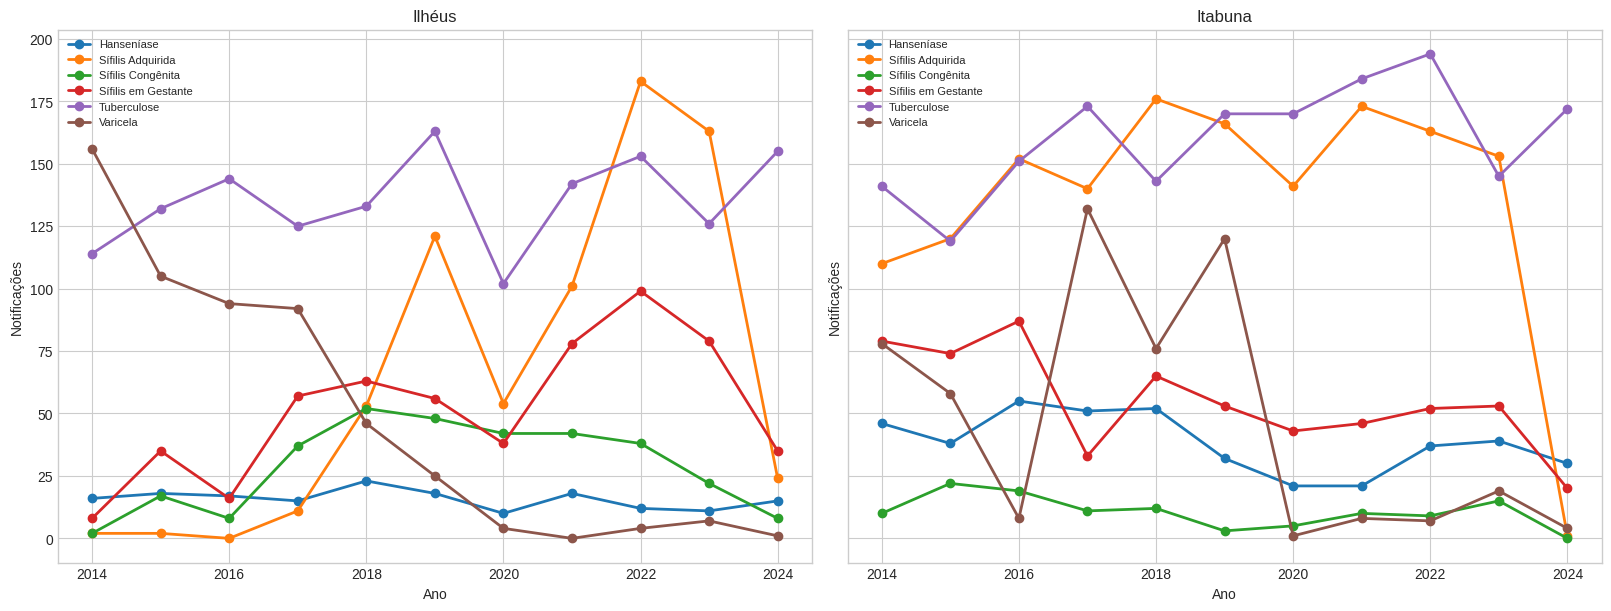

In [8]:
top_codes = ranking_geral_df.head(6)["agravo"].tolist()
evolucao_top_df = (
    serie_anual_df.loc[serie_anual_df["agravo"].isin(top_codes)]
    .groupby(["ano", "cidade", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
)

display(
    evolucao_top_df.pivot_table(
        index=["ano", "agravo", "agravo_nome"],
        columns="cidade",
        values="casos",
        aggfunc="sum",
        fill_value=0,
    ).reset_index().head(30)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, constrained_layout=True)
for ax, cidade in zip(axes, CITY_CODES):
    base = evolucao_top_df.loc[evolucao_top_df["cidade"] == cidade]
    for agravo, grupo in base.groupby("agravo"):
        label = AGRAVO_LABELS.get(agravo, agravo)
        ax.plot(grupo["ano"], grupo["casos"], marker="o", linewidth=2, label=label)
    ax.set_title(cidade)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Notificações")
    ax.legend(fontsize=8)
plt.show()

## 6. Mudanca entre periodos

Para enxergar deslocamentos de tendencia, comparamos 2014-2018 contra 2019-2024 em cada cidade.

In [9]:
serie_periodo_df = serie_anual_df.copy()
serie_periodo_df["periodo"] = serie_periodo_df["ano"].apply(
    lambda ano: "2014-2018" if ano <= 2018 else "2019-2024"
)

periodos_df = (
    serie_periodo_df.groupby(["cidade", "agravo", "agravo_nome", "periodo"], as_index=False)["casos"]
    .sum()
    .pivot(index=["cidade", "agravo", "agravo_nome"], columns="periodo", values="casos")
    .fillna(0)
    .reset_index()
)
periodos_df["variacao_abs"] = periodos_df["2019-2024"] - periodos_df["2014-2018"]
periodos_df["variacao_pct"] = (
    periodos_df["variacao_abs"] / periodos_df["2014-2018"].replace(0, float("nan")) * 100
).round(1)
periodos_df["Total"] = periodos_df["2014-2018"] + periodos_df["2019-2024"]

print("Maiores aumentos absolutos")
display(periodos_df.sort_values("variacao_abs", ascending=False).head(15))

print("Maiores quedas absolutas")
display(periodos_df.sort_values("variacao_abs", ascending=True).head(15))

Maiores aumentos absolutos


periodo,cidade,agravo,agravo_nome,2014-2018,2019-2024,variacao_abs,variacao_pct,Total
19,Ilhéus,SIFA,Sífilis Adquirida,68,646,578,850.0,714
54,Itabuna,TUBE,Tuberculose,727,1035,308,42.4,1762
21,Ilhéus,SIFG,Sífilis em Gestante,179,385,206,115.1,564
26,Ilhéus,TUBE,Tuberculose,648,841,193,29.8,1489
47,Itabuna,SIFA,Sífilis Adquirida,698,797,99,14.2,1495
20,Ilhéus,SIFC,Sífilis Congênita,116,200,84,72.4,316
0,Ilhéus,CHAG,Doença de Chagas Aguda,0,61,61,NaN,61
39,Itabuna,LEPT,Leptospirose,58,105,47,81.0,163
41,Itabuna,MALA,Malária,1,31,30,3000.0,32
30,Itabuna,DERM,Dermatoses ocupacionais,3,22,19,633.3,25


Maiores quedas absolutas


periodo,cidade,agravo,agravo_nome,2014-2018,2019-2024,variacao_abs,variacao_pct,Total
27,Ilhéus,VARC,Varicela,493,41,-452,-91.7,534
55,Itabuna,VARC,Varicela,352,159,-193,-54.8,511
49,Itabuna,SIFG,Sífilis em Gestante,338,267,-71,-21.0,605
12,Ilhéus,LTAN,Leishmaniose Tegumentar Americana,160,91,-69,-43.1,251
36,Itabuna,HANS,Hanseníase,242,180,-62,-25.6,422
40,Itabuna,LTAN,Leishmaniose Tegumentar Americana,46,14,-32,-69.6,60
29,Itabuna,COQU,Coqueluche,37,5,-32,-86.5,42
48,Itabuna,SIFC,Sífilis Congênita,74,42,-32,-43.2,116
42,Itabuna,MENI,Meningite,71,46,-25,-35.2,117
32,Itabuna,ESQU,Esquistossomose,27,4,-23,-85.2,31


## 7. Anos de pico e mapa de calor

Este bloco ajuda a identificar em quais anos cada agravo concentrou mais notificações no consolidado das duas cidades.

,agravo,agravo_nome,ano_pico,casos_no_pico
0,TUBE,Tuberculose,2022,347
1,SIFA,Sífilis Adquirida,2022,346
2,VARC,Varicela,2014,234
3,SIFG,Sífilis em Gestante,2022,151
4,HANS,Hanseníase,2018,75
5,LEPT,Leptospirose,2022,75
6,LTAN,Leishmaniose Tegumentar Americana,2014,70
7,SIFC,Sífilis Congênita,2018,64
8,MALA,Malária,2021,27
9,MENI,Meningite,2015,26


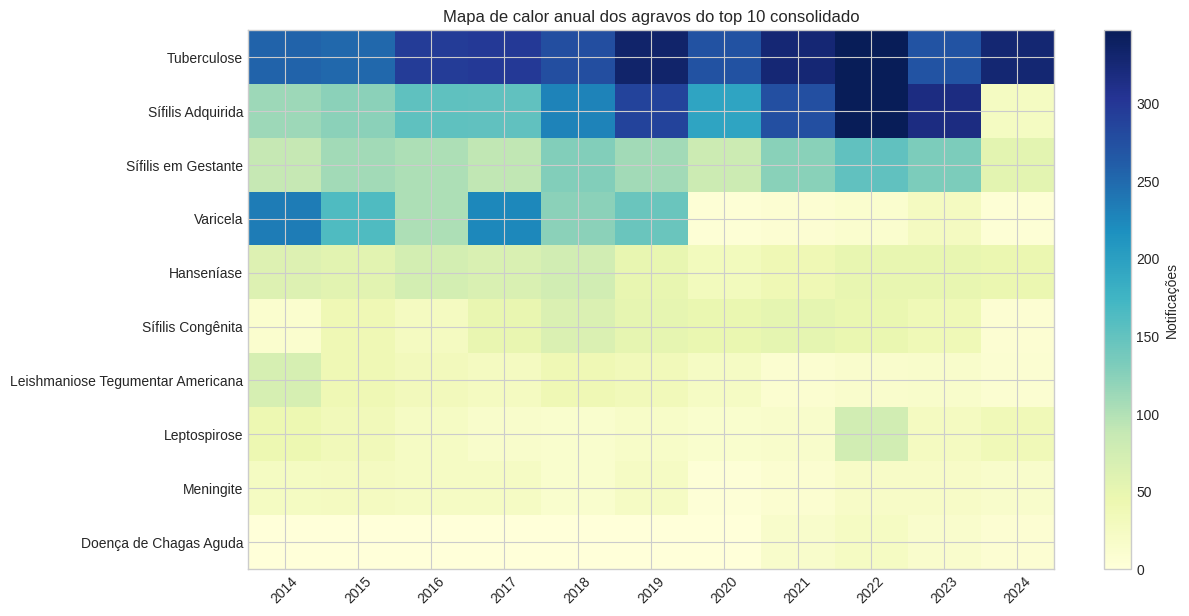

In [10]:
serie_total_agravo_ano_df = (
    serie_anual_df.groupby(["ano", "agravo", "agravo_nome"], as_index=False)["casos"]
    .sum()
)

picos_df = (
    serie_total_agravo_ano_df.sort_values(["agravo", "casos"], ascending=[True, False])
    .groupby(["agravo", "agravo_nome"], as_index=False)
    .first()
    .rename(columns={"ano": "ano_pico", "casos": "casos_no_pico"})
    .sort_values("casos_no_pico", ascending=False)
    .reset_index(drop=True)
)

display(picos_df.head(15))

heatmap_codes = ranking_geral_df["agravo"].tolist()
heatmap_df = (
    serie_total_agravo_ano_df.loc[serie_total_agravo_ano_df["agravo"].isin(heatmap_codes)]
    .pivot(index="agravo_nome", columns="ano", values="casos")
    .fillna(0)
)
heatmap_df = heatmap_df.loc[ranking_geral_df.set_index("agravo")["agravo_nome"]]

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Mapa de calor anual dos agravos do top 10 consolidado")
fig.colorbar(im, ax=ax, label="Notificações")
plt.show()

## 8. Direcionamento para o projeto preditivo

O objetivo final do projeto não é apenas descrever o passado. A ideia é escolher uma doença com base histórica suficientemente consistente e, a partir dela, construir modelos preditivos de inteligência artificial para auxiliar na tomada de decisões.

Neste ponto, eu não devo escolher a doença apenas porque ela aparece no top 10. Para uma previsão minimamente defensável, eu preciso observar se a série tem volume, continuidade mensal, poucos meses zerados, variação temporal interpretável e possibilidade de ser enriquecida com outras fontes confiáveis.

In [11]:
monthly_counts_df, monthly_issues_df = build_monthly_city_counts(
    download_audit_df,
    CITY_CODES,
    DATA_DIR,
    AGRAVO_LABELS,
)
candidate_inventory_df = build_candidate_inventory(monthly_counts_df)

if not monthly_issues_df.empty:
    print("Arquivos sem coluna de data/cidade suficiente para a série mensal:")
    display(monthly_issues_df)

colunas_inventario = [
    "agravo",
    "agravo_nome",
    "score_modelagem",
    "total_casos",
    "media_mensal",
    "max_mensal",
    "meses_com_caso",
    "pct_meses_zerados",
    "casos_2014_2018",
    "casos_2019_2024",
    "variacao_abs_periodos",
    "indice_sazonalidade",
]

display(candidate_inventory_df[colunas_inventario].head(15))

,agravo,agravo_nome,score_modelagem,total_casos,media_mensal,max_mensal,meses_com_caso,pct_meses_zerados,casos_2014_2018,casos_2019_2024,variacao_abs_periodos,indice_sazonalidade
0,TUBE,Tuberculose,94.6,3095,23.45,41,132,0.0,1300,1795,495,0.10
1,SIFA,Sífilis Adquirida,92.0,2209,16.73,54,121,8.3,766,1443,677,0.15
2,SIFG,Sífilis em Gestante,88.0,1169,8.86,21,127,3.8,517,652,135,0.12
3,HANS,Hanseníase,85.2,595,4.51,17,128,3.0,331,264,-67,0.26
4,VARC,Varicela,84.1,1045,7.92,53,90,31.8,845,200,-645,0.50
5,SIFC,Sífilis Congênita,79.1,432,3.27,15,110,16.7,190,242,52,0.27
6,LTAN,Leishmaniose Tegumentar Americana,78.3,311,2.36,22,109,17.4,206,105,-101,0.28
7,LEPT,Leptospirose,77.8,311,2.36,51,105,20.5,128,183,55,0.47
8,MENI,Meningite,68.2,200,1.52,5,97,26.5,109,91,-18,0.31
9,CHAG,Doença de Chagas Aguda,65.4,61,0.46,6,27,79.5,0,61,61,0.48


Transformei a série anual em série mensal, porque modelos preditivos precisam de mais pontos no tempo. Com dados de 2014 a 2024, a granularidade mensal produz aproximadamente 132 meses por cidade, o que é muito mais adequado do que apenas 11 anos.

Em seguida, eu avaliei cada agravo por critérios objetivos: volume total de notificações, média mensal, quantidade de meses com pelo menos um caso, percentual de meses zerados, diferença entre 2014-2018 e 2019-2024 e um índice simples de sazonalidade. O `score_modelagem` não é um resultado epidemiológico; ele é apenas uma triagem técnica para indicar quais doenças parecem mais adequadas para modelagem preditiva.

In [12]:
shortlist_df = candidate_inventory_df.loc[
    (candidate_inventory_df["total_casos"] >= 200)
    & (candidate_inventory_df["pct_meses_zerados"] <= 45)
].copy()

display(shortlist_df[colunas_inventario].head(10))

melhor_candidato = shortlist_df.iloc[0] if not shortlist_df.empty else candidate_inventory_df.iloc[0]
print("Candidato técnico mais forte no recorte atual:")
print(f"{melhor_candidato['agravo_nome']} ({melhor_candidato['agravo']})")
print(f"Total de notificações: {int(melhor_candidato['total_casos'])}")
print(f"Meses zerados: {melhor_candidato['pct_meses_zerados']}%")
print(f"Score de modelagem: {melhor_candidato['score_modelagem']}")

,agravo,agravo_nome,score_modelagem,total_casos,media_mensal,max_mensal,meses_com_caso,pct_meses_zerados,casos_2014_2018,casos_2019_2024,variacao_abs_periodos,indice_sazonalidade
0,TUBE,Tuberculose,94.6,3095,23.45,41,132,0.0,1300,1795,495,0.10
1,SIFA,Sífilis Adquirida,92.0,2209,16.73,54,121,8.3,766,1443,677,0.15
2,SIFG,Sífilis em Gestante,88.0,1169,8.86,21,127,3.8,517,652,135,0.12
3,HANS,Hanseníase,85.2,595,4.51,17,128,3.0,331,264,-67,0.26
4,VARC,Varicela,84.1,1045,7.92,53,90,31.8,845,200,-645,0.50
5,SIFC,Sífilis Congênita,79.1,432,3.27,15,110,16.7,190,242,52,0.27
6,LTAN,Leishmaniose Tegumentar Americana,78.3,311,2.36,22,109,17.4,206,105,-101,0.28
7,LEPT,Leptospirose,77.8,311,2.36,51,105,20.5,128,183,55,0.47
8,MENI,Meningite,68.2,200,1.52,5,97,26.5,109,91,-18,0.31


Candidato técnico mais forte no recorte atual:
Tuberculose (TUBE)
Total de notificações: 3095
Meses zerados: 0.0%
Score de modelagem: 94.6


## 9. Conclusão e encaminhamento para o sistema de apoio à decisão

A análise mostra que o projeto não deve ser tratado apenas como uma previsão agregada de incidência para anos futuros. O resultado mais útil para a gestão é transformar a série histórica do SINAN em um sistema de apoio à decisão, capaz de indicar quais agravos merecem atenção, em quais períodos do ano e, na próxima etapa, em quais territórios da cidade as ações devem ser priorizadas.

No recorte de 2014 a 2024, Itabuna concentrou 5.420 notificações e Ilhéus 4.417. A diferença entre as cidades existe, mas o ponto mais importante é que as notificações são muito concentradas em poucos agravos. No consolidado, Tuberculose, Sífilis Adquirida e Sífilis em Gestante somam aproximadamente 69,2% das notificações analisadas. Isso indica que o sistema deve começar por poucos agravos prioritários, em vez de tentar modelar todas as doenças ao mesmo tempo.

A Tuberculose aparece como o agravo tecnicamente mais forte para modelagem: teve 3.095 casos na base mensal consolidada, presença em todos os 132 meses analisados, nenhum mês zerado e aumento de 1.300 casos em 2014-2018 para 1.795 em 2019-2024. Ela é adequada como primeiro piloto porque tem volume, continuidade temporal e relevância sanitária. Para a gestão, o modelo poderia apoiar busca ativa, planejamento de equipes, reforço de diagnóstico, acompanhamento de tratamento e priorização territorial.

A Sífilis Adquirida também se destaca: foram 2.209 casos, com crescimento expressivo entre os períodos, saindo de 766 casos em 2014-2018 para 1.443 em 2019-2024. Em Ilhéus, o aumento foi particularmente forte: de 68 para 646 casos. Esse padrão sugere que, além de prever volume esperado, o sistema pode apontar necessidade de intensificar testagem, campanhas educativas, distribuição de preservativos, rastreamento e tratamento oportuno.

A Sífilis em Gestante é outro agravo importante para decisão, porque combina alta continuidade mensal, relevância para vigilância materno-infantil e impacto direto na prevenção da Sífilis Congênita. Mesmo que o objetivo não seja apenas prever o futuro, o modelo pode sinalizar períodos e territórios onde a rede deve reforçar pré-natal, testagem rápida, tratamento de gestantes e parcerias com a atenção básica.

Alguns agravos, como Varicela e Leptospirose, não aparecem como melhores candidatos apenas pelo volume total. A Varicela teve queda forte depois de 2018, mas possui sazonalidade mais alta; a Leptospirose tem volume menor, porém picos mensais e sazonalidade relevantes. Esses casos são úteis para mostrar ao professor que o sistema não precisa gerar uma única resposta para todos os agravos: para alguns, a decisão pode ser campanha preventiva em meses específicos; para outros, pode ser preparação de equipes, alerta territorial ou resposta rápida a surtos.

Assim, o novo objetivo do projeto deve ser descrito como: construir uma base analítica mensal e territorializada para apoiar decisões dos gestores de saúde, indicando agravo prioritário, período de maior risco, tendência recente e local provável de concentração dos casos. A previsão deixa de ser o produto final isolado e passa a ser um componente dentro de um painel ou ferramenta de priorização.

Para isso, o próximo passo técnico é sair do agregado por cidade e buscar a maior granularidade espacial possível. O notebook atual trabalha com Ilhéus e Itabuna como unidades de análise, mas uma ação de saúde pública precisa ser mais localizada. Uma checagem inicial dos CSVs mostra que os campos de localização mais presentes ainda são municipais, como `ID_MUNICIP`, `ID_MN_RESI` e `ID_RG_RESI`; não apareceu um campo de bairro padronizado e confiável em todos os arquivos. Isso não inviabiliza o projeto, mas define a próxima tarefa: verificar, para os agravos escolhidos, se há campos aproveitáveis de bairro, comunidade, zona, endereço ou território de residência. Se houver bairro preenchido com qualidade suficiente, o modelo deve gerar mapas por bairro. Se não houver, será necessário usar outra estratégia: padronizar campos de endereço, cruzar com bases territoriais da atenção básica, usar setores censitários ou trabalhar com áreas de abrangência das unidades de saúde.

A proposta para apresentar ao professor é começar com um piloto em Tuberculose e Sífilis, porque são os agravos com melhor combinação de volume, continuidade e impacto para gestão. Em seguida, montar uma base mensal por território, calcular taxa por 100 mil habitantes quando houver população disponível e criar mapas de calor por bairro/território. Com isso, o sistema poderá responder perguntas práticas: onde intensificar busca ativa, onde reforçar testagem, em quais meses antecipar campanhas, quais unidades precisam de mais insumos e quais áreas apresentam piora recente.

Portanto, a contribuição central do projeto passa a ser menos “acertar o número exato de casos em 2025 ou 2026” e mais entregar inteligência operacional: transformar dados históricos de notificação em recomendações localizadas, temporais e acionáveis para a vigilância em saúde.


## 10. Preenchimento da unidade notificadora

Para avaliar se a unidade notificadora pode ser usada como aproximação operacional do território de atendimento, calculei a completude do campo `ID_UNIDADE` em cada agravo da base pública baixada. Considerei `ID_UNIDADE` como unidade notificadora original; campos como `ID_UNID_AT`, `PRE_UNIPRE` ou `ANT_LOCAL_` não foram misturados aqui porque representam outros conceitos, como unidade atual de atendimento, unidade de pré-natal ou local de nascimento.

In [13]:
from pathlib import Path

unidade_records = []
unidade_coluna = "ID_UNIDADE"

for _, row in download_audit_df.iterrows():
    csv_path = Path(row["csv_path"])
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        continue

    try:
        header = pd.read_csv(csv_path, nrows=0)
    except pd.errors.EmptyDataError:
        continue

    columns = header.columns.tolist()
    if not columns:
        continue

    tem_id_unidade = unidade_coluna in columns
    read_columns = [unidade_coluna] if tem_id_unidade else [columns[0]]
    file_df = pd.read_csv(csv_path, usecols=read_columns, dtype="string")
    total_registros = len(file_df)
    unidade_preenchida = 0

    if tem_id_unidade:
        unidade_series = file_df[unidade_coluna].str.strip().replace("", pd.NA)
        unidade_preenchida = int(unidade_series.notna().sum())

    unidade_records.append(
        {
            "agravo": row["agravo"],
            "agravo_nome": row["agravo_nome"],
            "arquivo": row["stem"],
            "tem_id_unidade": tem_id_unidade,
            "registros_total": total_registros,
            "registros_com_id_unidade": total_registros if tem_id_unidade else 0,
            "unidade_notificadora_preenchida": unidade_preenchida,
        }
    )

unidade_notificadora_df = pd.DataFrame(unidade_records)

resumo_unidade_notificadora_df = (
    unidade_notificadora_df.groupby(["agravo", "agravo_nome"], as_index=False)
    .agg(
        arquivos_analisados=("arquivo", "nunique"),
        arquivos_com_id_unidade=("tem_id_unidade", "sum"),
        registros_total=("registros_total", "sum"),
        registros_com_id_unidade=("registros_com_id_unidade", "sum"),
        unidade_notificadora_preenchida=("unidade_notificadora_preenchida", "sum"),
    )
)

registros_total = resumo_unidade_notificadora_df["registros_total"].where(
    resumo_unidade_notificadora_df["registros_total"] > 0
)
registros_com_id_unidade = resumo_unidade_notificadora_df["registros_com_id_unidade"].where(
    resumo_unidade_notificadora_df["registros_com_id_unidade"] > 0
)

resumo_unidade_notificadora_df["pct_cobertura_campo_id_unidade"] = (
    resumo_unidade_notificadora_df["registros_com_id_unidade"] / registros_total * 100
).round(1)
resumo_unidade_notificadora_df["pct_preenchimento_unidade_notificadora"] = (
    resumo_unidade_notificadora_df["unidade_notificadora_preenchida"] / registros_total * 100
).round(1)
resumo_unidade_notificadora_df["pct_preenchimento_quando_campo_existe"] = (
    resumo_unidade_notificadora_df["unidade_notificadora_preenchida"]
    / registros_com_id_unidade
    * 100
).round(1)
resumo_unidade_notificadora_df["situacao_campo"] = resumo_unidade_notificadora_df.apply(
    lambda row: "ausente na base pública"
    if row["arquivos_com_id_unidade"] == 0
    else "presente em todos os arquivos"
    if row["arquivos_com_id_unidade"] == row["arquivos_analisados"]
    else "presente em parte dos arquivos",
    axis=1,
)

display(
    resumo_unidade_notificadora_df.sort_values(
        ["pct_preenchimento_unidade_notificadora", "registros_total"],
        ascending=[True, False],
    ).reset_index(drop=True)
)


,agravo,agravo_nome,arquivos_analisados,arquivos_com_id_unidade,registros_total,registros_com_id_unidade,unidade_notificadora_preenchida,pct_cobertura_campo_id_unidade,pct_preenchimento_unidade_notificadora,pct_preenchimento_quando_campo_existe,situacao_campo
0,SIFA,Sífilis Adquirida,11,0,1454080,0,0,0.0,0.0,NaN,ausente na base pública
1,TUBE,Tuberculose,11,0,1041211,0,0,0.0,0.0,NaN,ausente na base pública
2,SIFG,Sífilis em Gestante,11,0,626880,0,0,0.0,0.0,NaN,ausente na base pública
3,SIFC,Sífilis Congênita,11,0,250310,0,0,0.0,0.0,NaN,ausente na base pública
4,TRAC,Inquérito de Tracoma,11,11,112330,112330,110464,100.0,98.3,98.3,presente em todos os arquivos
5,NTRA,Notificação de Tracoma,11,11,25397,25397,25067,100.0,98.7,98.7,presente em todos os arquivos
6,VARC,Varicela,11,11,385736,385736,385733,100.0,100.0,100.0,presente em todos os arquivos
7,HANS,Hanseníase,11,11,349412,349412,349392,100.0,100.0,100.0,presente em todos os arquivos
8,MENI,Meningite,11,11,248964,248964,248963,100.0,100.0,100.0,presente em todos os arquivos
9,LEPT,Leptospirose,11,11,192872,192872,192872,100.0,100.0,100.0,presente em todos os arquivos
